In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

gradient_boosting_estimators_dict = {
    "Gradient Boosting": estimators_dict["Gradient Boosting"],
    "Gradient Boosting Balanced": estimators_dict["Gradient Boosting Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_gb, threshold_comparison_gb, confusion_results_gb, trained_models_gb, interpretation_results_gb = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=gradient_boosting_estimators_dict,
    target=target
)

general_comparison_gb.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
3,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.5,0.787,0.409,0.732,0.525,0.800,0,8,22
17,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.5,0.810,0.436,0.620,0.512,0.824,3,8,25
11,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.5,0.796,0.414,0.648,0.505,0.779,0,9,24
19,Modelo 3 — Rendimento Quantitativo,Gradient Boosting Balanced,0.5,0.810,0.433,0.592,0.500,0.805,4,6,19
9,Modelo 5 — Estabilidade e Benefícios,Gradient Boosting Balanced,0.5,0.780,0.393,0.676,0.497,0.771,0,9,24
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.5,0.819,0.446,0.521,0.481,0.782,7,11,43
23,Modelo 5 — Antiguidade Organizacional,Gradient Boosting Balanced,0.5,0.789,0.396,0.592,0.475,0.770,5,6,20
21,Modelo 4 — Experiência Profissional,Gradient Boosting Balanced,0.5,0.782,0.387,0.606,0.473,0.773,4,6,19
5,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.5,0.760,0.362,0.648,0.465,0.773,0,8,21
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Gradient Boosting Balanced,0.5,0.800,0.409,0.535,0.463,0.780,3,8,24


In [4]:
best_thresholds_gb = threshold_comparison_gb.loc[
    threshold_comparison_gb.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_gb.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
5,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.550,0.816,0.454,0.690,0.547,0.800
4,Modelo 2 — Nível Hierárquico,Gradient Boosting,0.275,0.832,0.483,0.606,0.537,0.801
7,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.625,0.857,0.562,0.507,0.533,0.824
6,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting,0.300,0.850,0.538,0.493,0.515,0.828
9,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.575,0.819,0.452,0.592,0.512,0.773
8,Modelo 3 — Faixa Salarial,Gradient Boosting,0.275,0.834,0.487,0.535,0.510,0.785
21,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.500,0.796,0.414,0.648,0.505,0.779
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.550,0.839,0.500,0.507,0.503,0.782
20,Modelo 6 — Perfil Pessoal,Gradient Boosting,0.200,0.807,0.430,0.606,0.503,0.791
11,Modelo 3 — Rendimento Quantitativo,Gradient Boosting Balanced,0.500,0.810,0.433,0.592,0.500,0.805


In [5]:
top_5_best_gb = best_thresholds_gb.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_gb

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.550,0.816,0.454,0.690,0.547,0.800
1,Modelo 2 — Nível Hierárquico,Gradient Boosting,0.275,0.832,0.483,0.606,0.537,0.801
2,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.625,0.857,0.562,0.507,0.533,0.824
3,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting,0.300,0.850,0.538,0.493,0.515,0.828
4,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.575,0.819,0.452,0.592,0.512,0.773


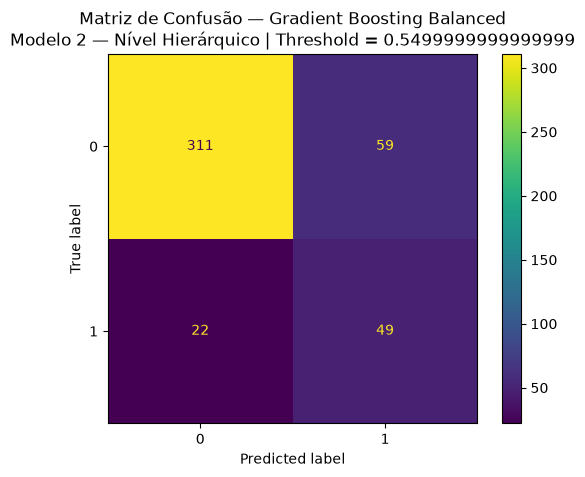

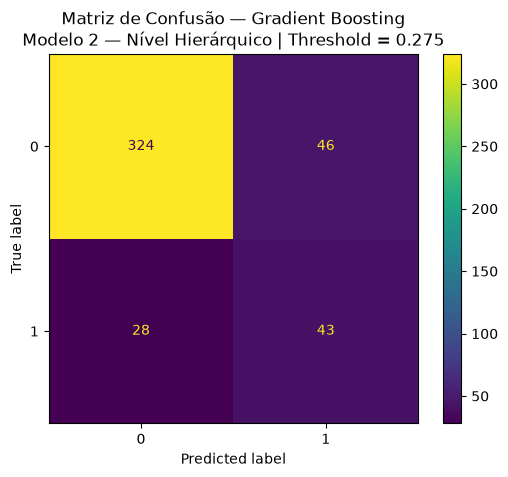

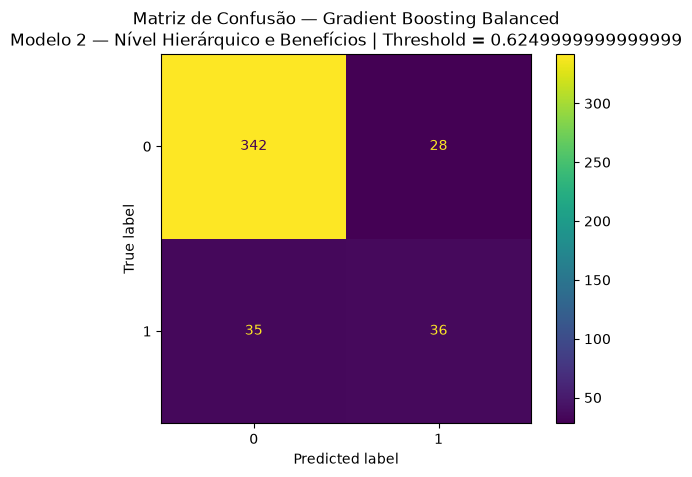

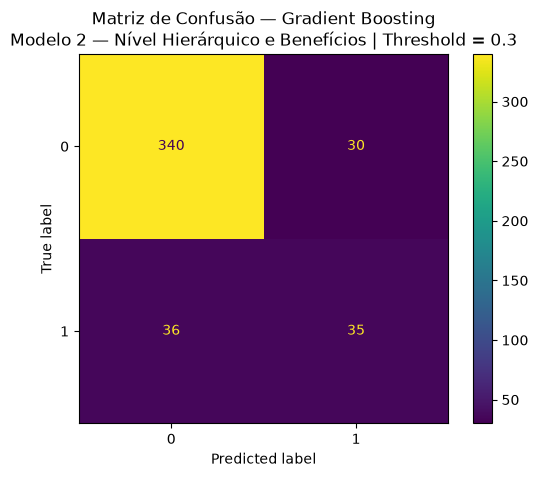

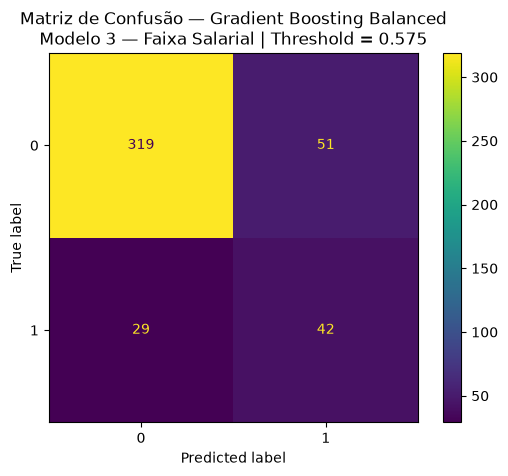

In [6]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(gradient_boosting_estimators_dict[model_name]["estimator"])
    balance_method = gradient_boosting_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

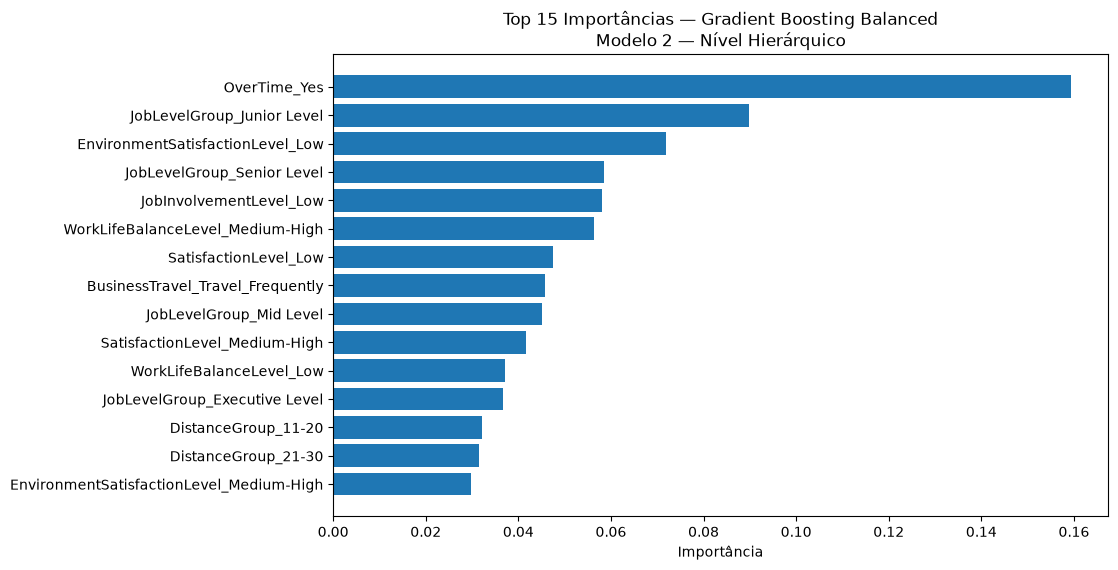

,Feature,Importance
0,OverTime_Yes,0.159418
2,JobLevelGroup_Junior Level,0.089756
10,EnvironmentSatisfactionLevel_Low,0.071861
4,JobLevelGroup_Senior Level,0.058548
7,JobInvolvementLevel_Low,0.058139
17,WorkLifeBalanceLevel_Medium-High,0.056333
13,SatisfactionLevel_Low,0.047466
5,BusinessTravel_Travel_Frequently,0.045778
3,JobLevelGroup_Mid Level,0.045095
14,SatisfactionLevel_Medium-High,0.041640


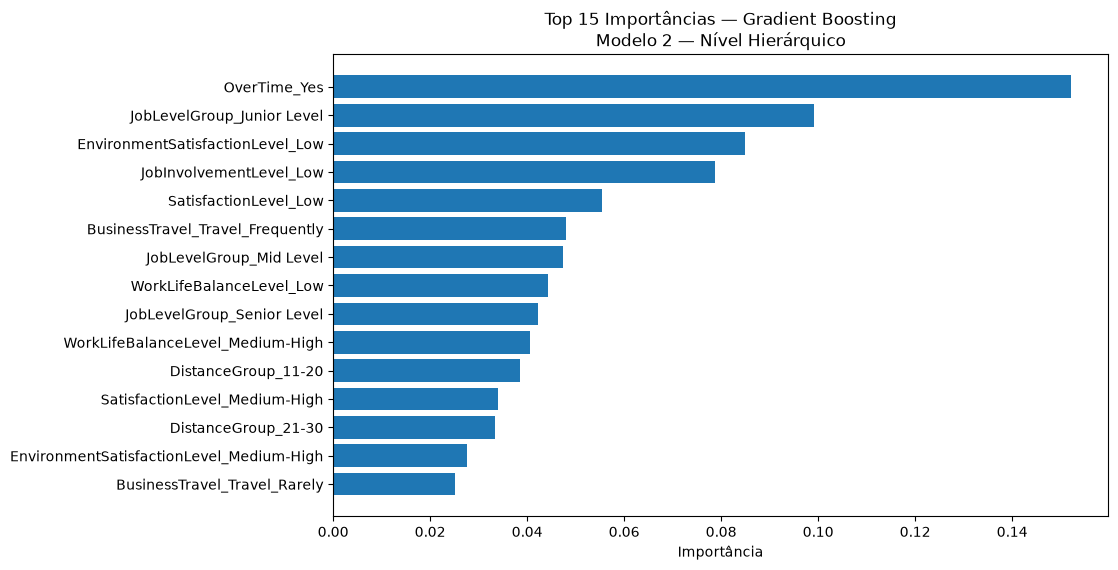

,Feature,Importance
0,OverTime_Yes,0.152180
2,JobLevelGroup_Junior Level,0.099088
10,EnvironmentSatisfactionLevel_Low,0.084966
7,JobInvolvementLevel_Low,0.078694
13,SatisfactionLevel_Low,0.055346
5,BusinessTravel_Travel_Frequently,0.047952
3,JobLevelGroup_Mid Level,0.047473
16,WorkLifeBalanceLevel_Low,0.044349
4,JobLevelGroup_Senior Level,0.042336
17,WorkLifeBalanceLevel_Medium-High,0.040601


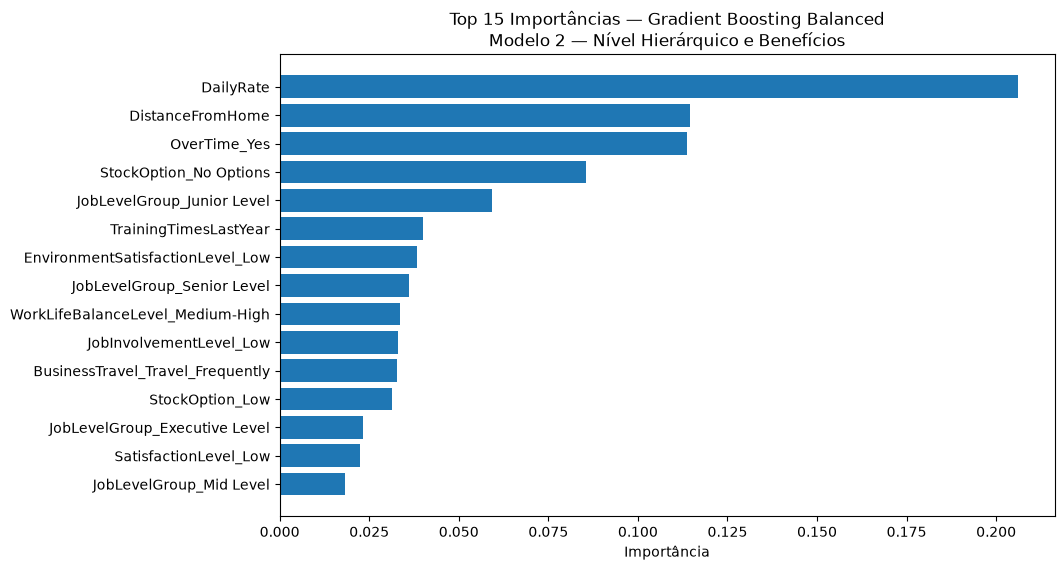

,Feature,Importance
1,DailyRate,0.206023
0,DistanceFromHome,0.114528
3,OverTime_Yes,0.113565
10,StockOption_No Options,0.085528
5,JobLevelGroup_Junior Level,0.059402
2,TrainingTimesLastYear,0.039970
16,EnvironmentSatisfactionLevel_Low,0.038229
7,JobLevelGroup_Senior Level,0.036104
23,WorkLifeBalanceLevel_Medium-High,0.033574
13,JobInvolvementLevel_Low,0.032988


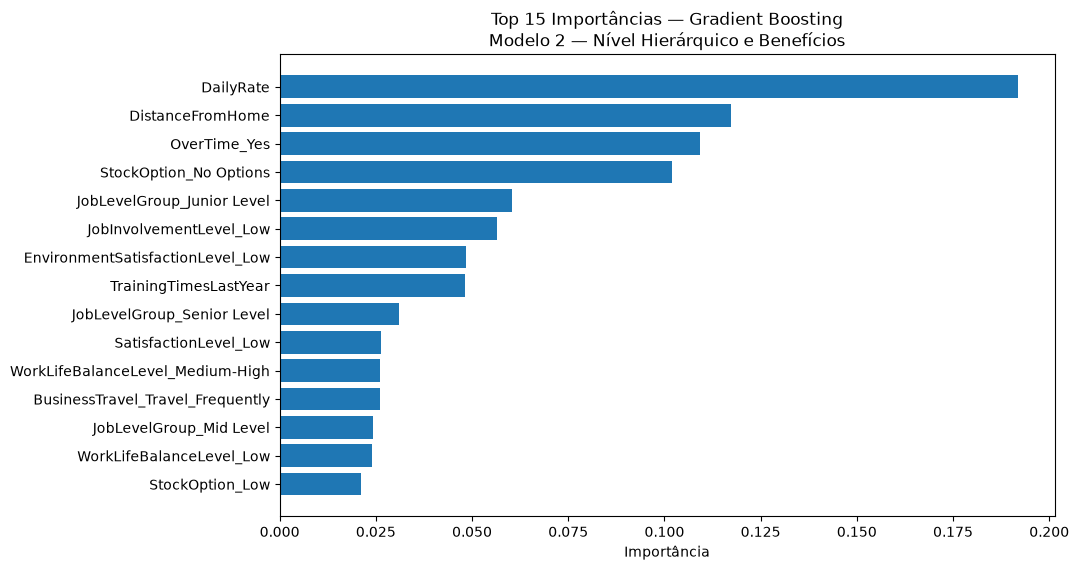

,Feature,Importance
1,DailyRate,0.191819
0,DistanceFromHome,0.117407
3,OverTime_Yes,0.109326
10,StockOption_No Options,0.102083
5,JobLevelGroup_Junior Level,0.060351
13,JobInvolvementLevel_Low,0.056467
16,EnvironmentSatisfactionLevel_Low,0.048326
2,TrainingTimesLastYear,0.048097
7,JobLevelGroup_Senior Level,0.030928
19,SatisfactionLevel_Low,0.026227


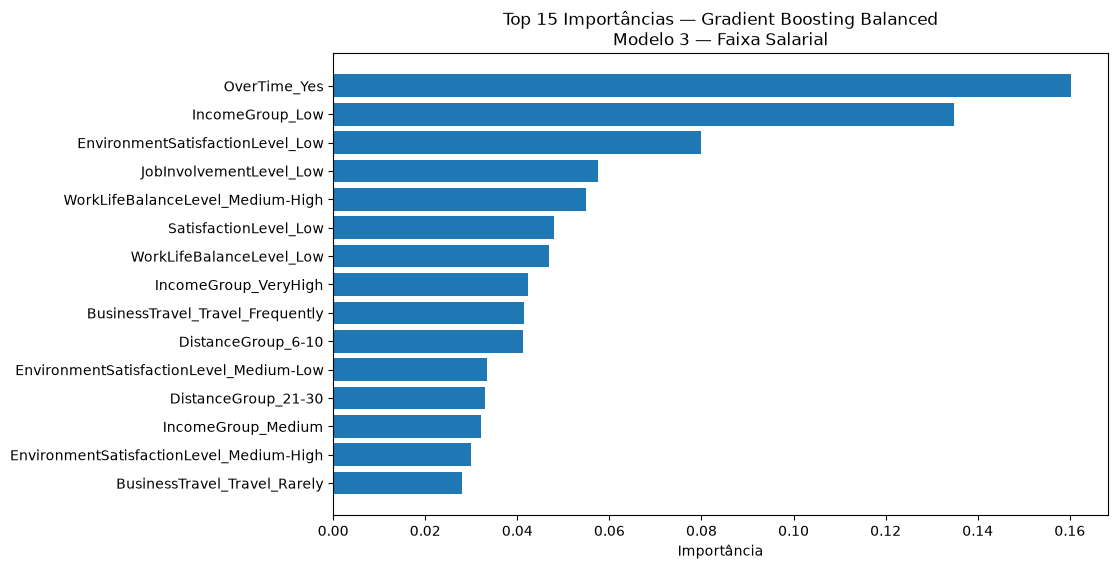

,Feature,Importance
0,OverTime_Yes,0.160315
1,IncomeGroup_Low,0.134774
9,EnvironmentSatisfactionLevel_Low,0.079868
6,JobInvolvementLevel_Low,0.057622
16,WorkLifeBalanceLevel_Medium-High,0.054968
12,SatisfactionLevel_Low,0.047931
15,WorkLifeBalanceLevel_Low,0.046918
3,IncomeGroup_VeryHigh,0.042408
4,BusinessTravel_Travel_Frequently,0.041370
20,DistanceGroup_6-10,0.041157


In [7]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_gb[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Gradient Boosting Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


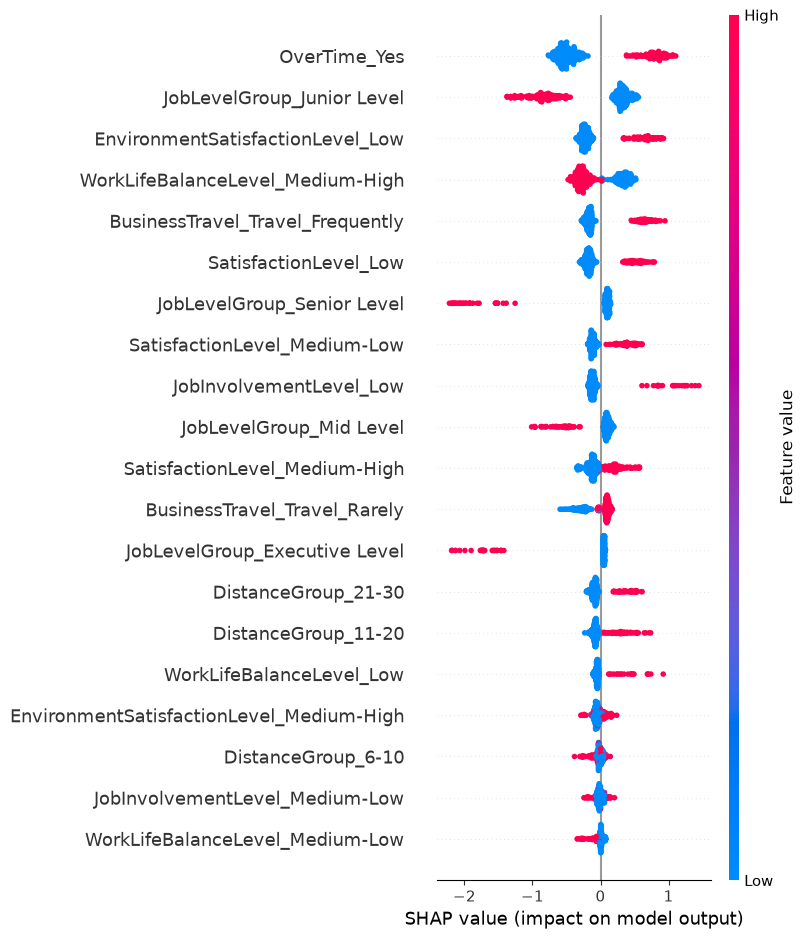

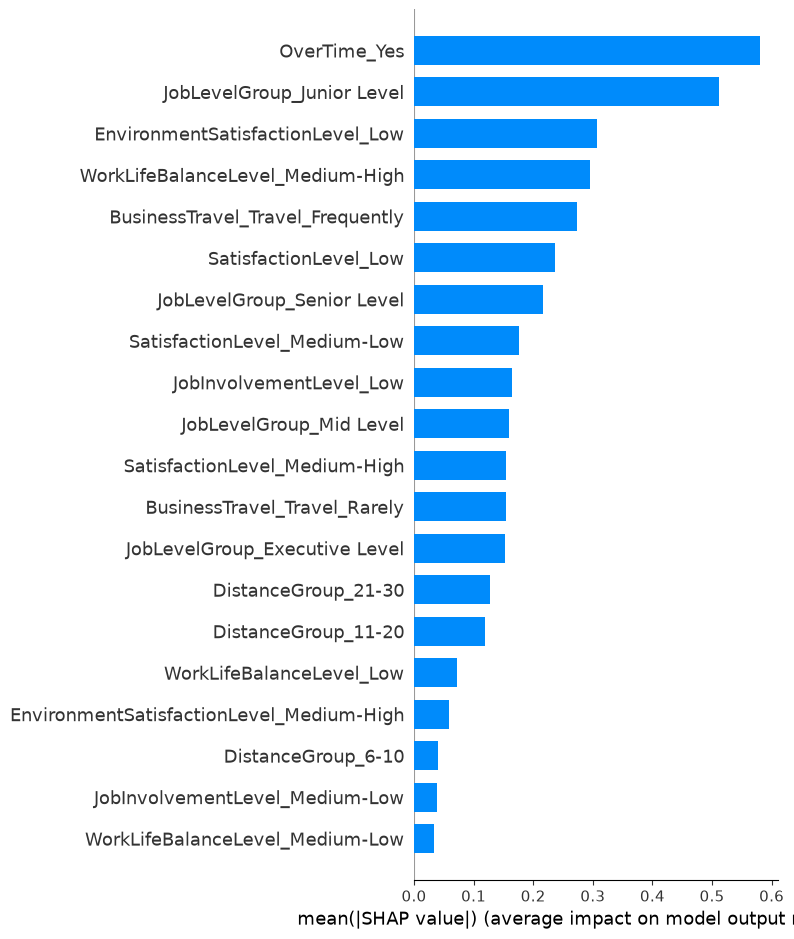

SHAP — Gradient Boosting | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


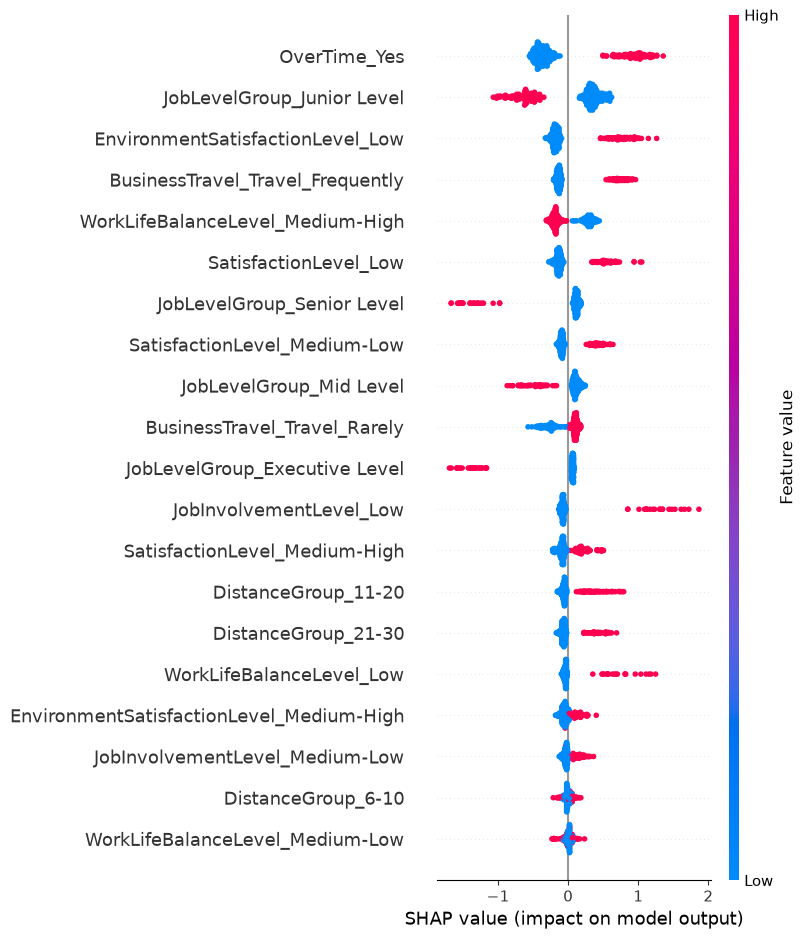

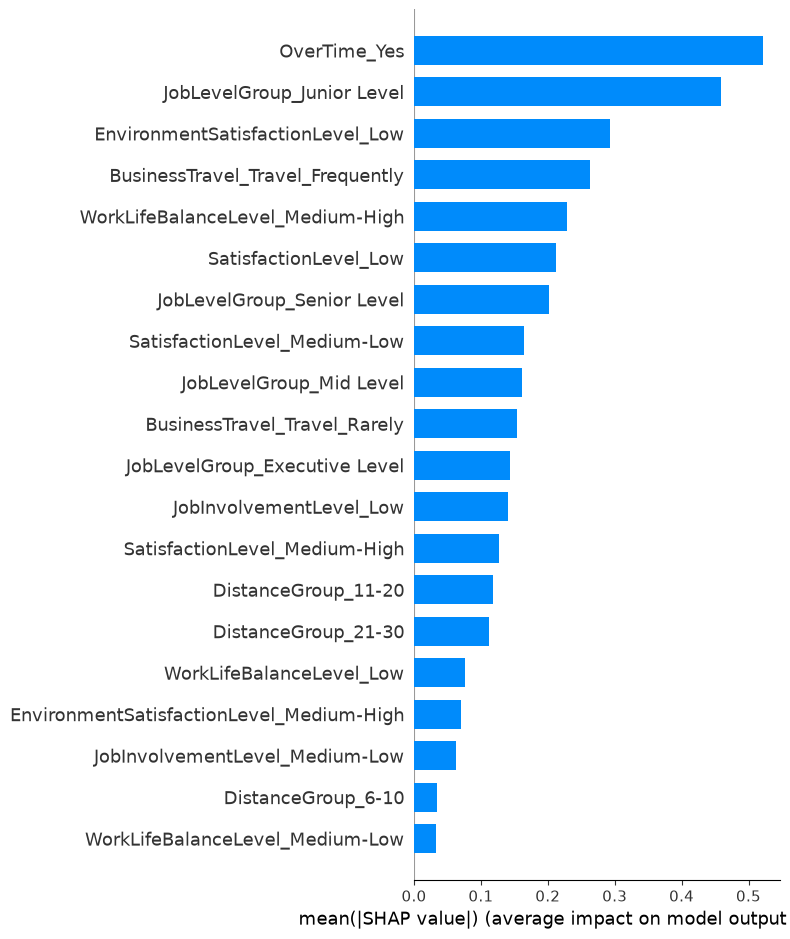

SHAP — Gradient Boosting Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


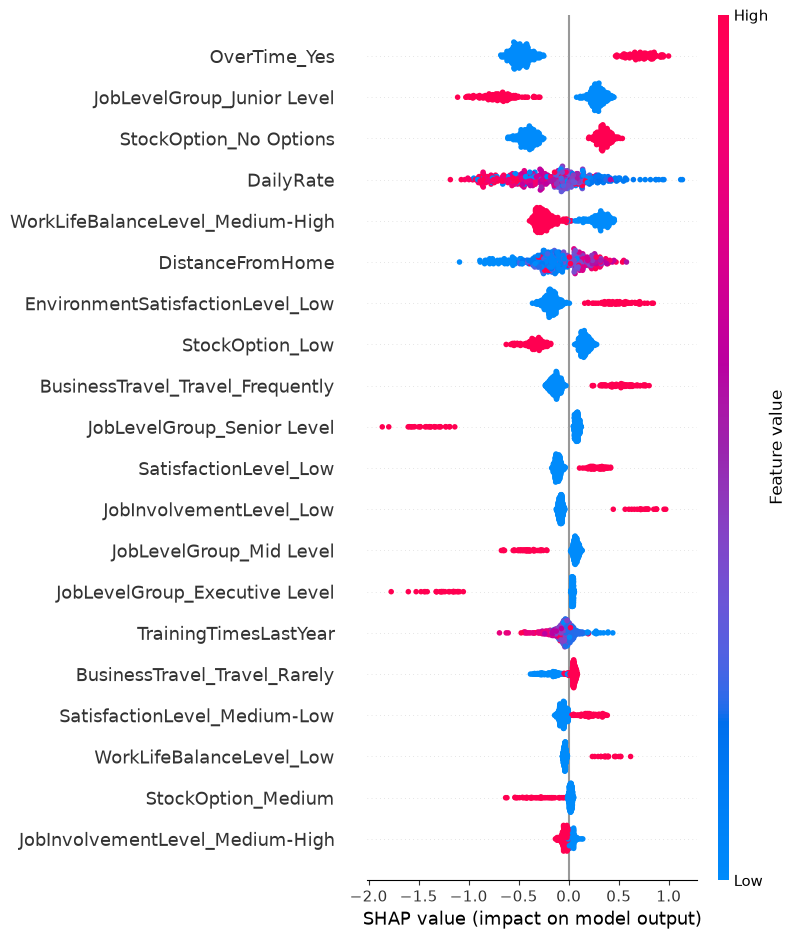

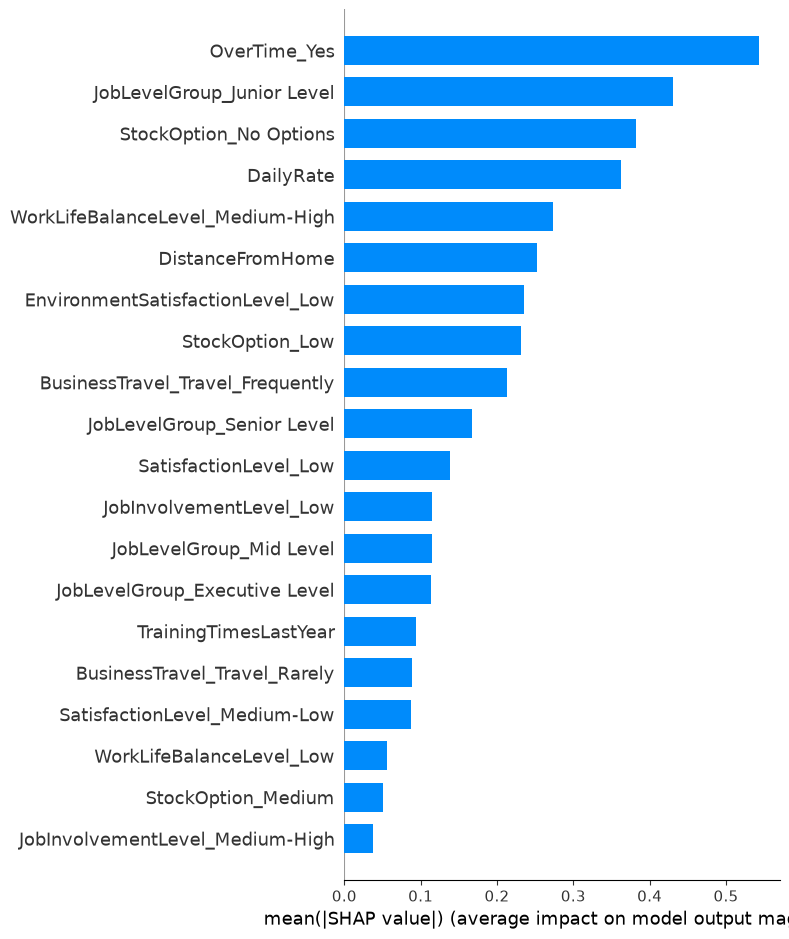

SHAP — Gradient Boosting | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


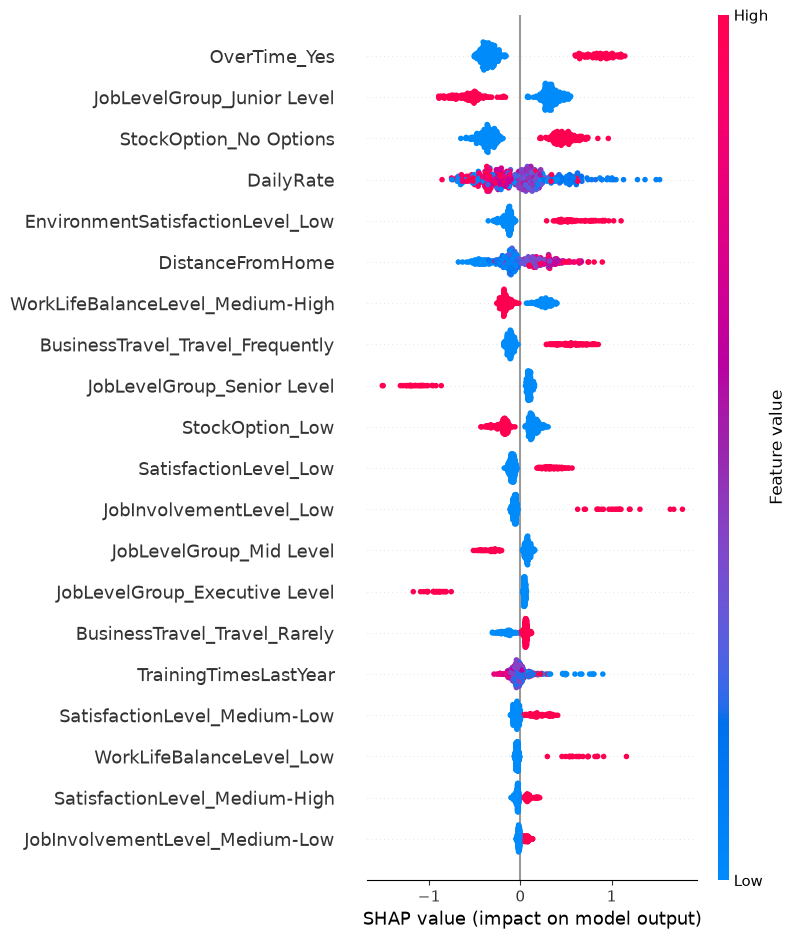

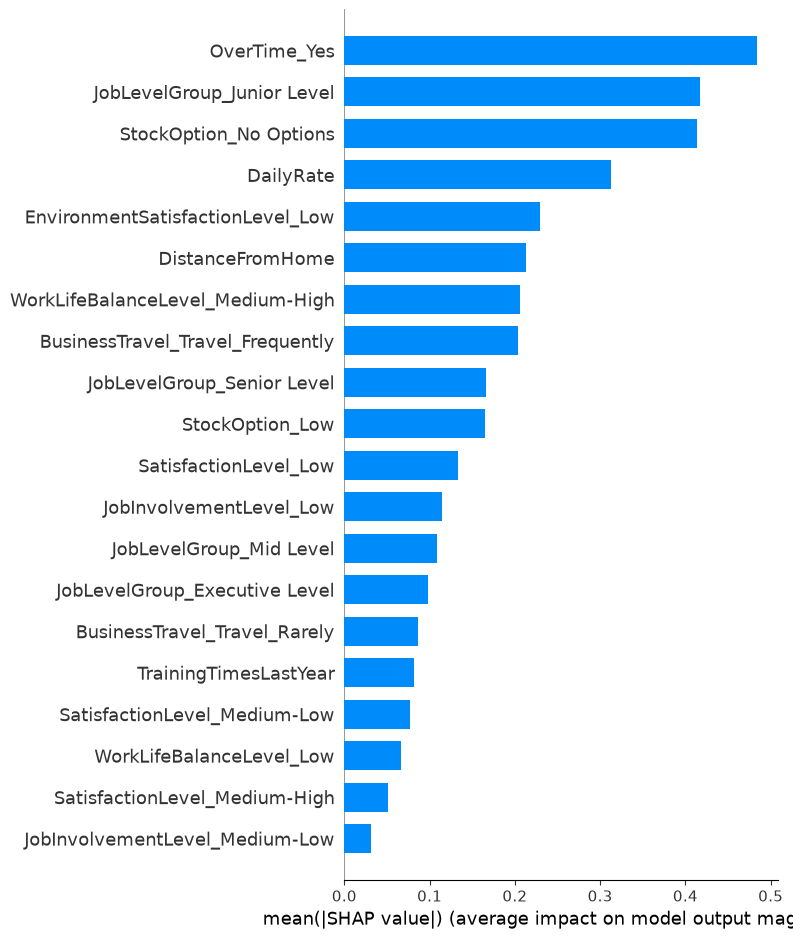

SHAP — Gradient Boosting Balanced | Modelo 3 — Faixa Salarial
(441, 21)
(441, 21)


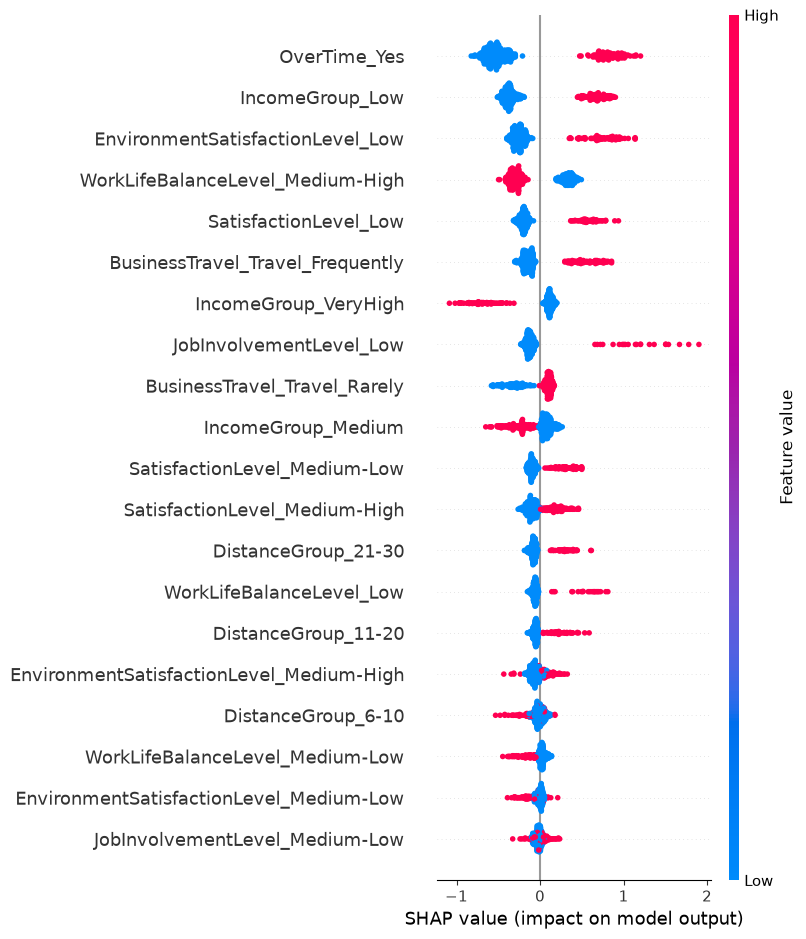

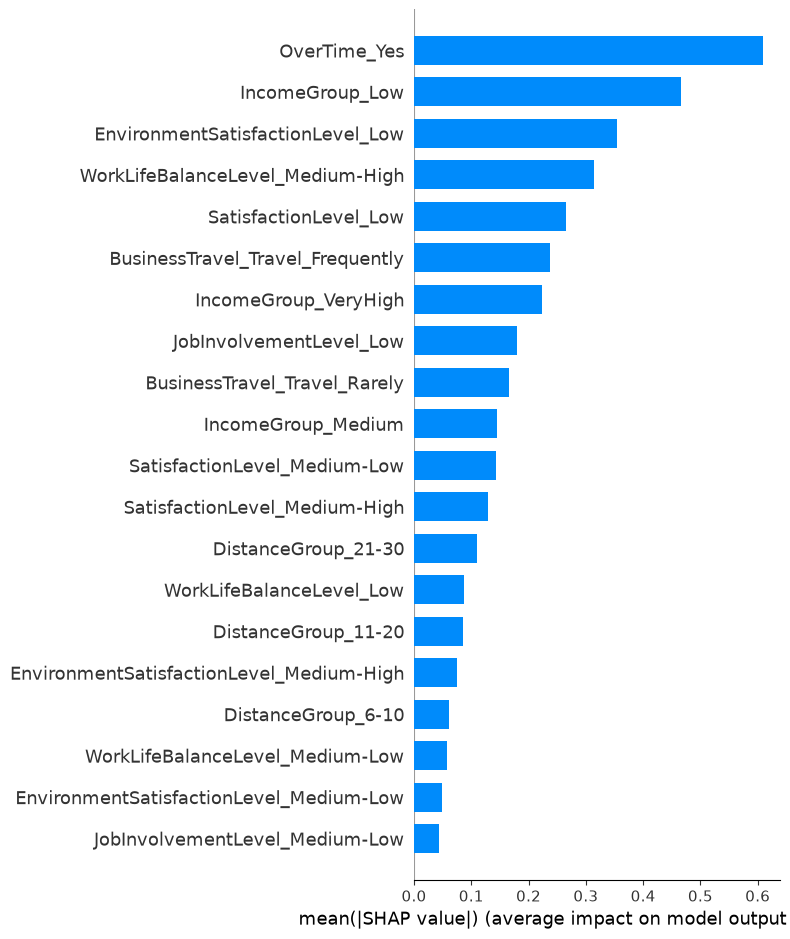

In [8]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(gradient_boosting_estimators_dict[model_name]["estimator"])
    balance_method = gradient_boosting_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_gradient = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Gradient Boosting": estimators_dict["Gradient Boosting"],
        "Gradient Boosting Balanced": estimators_dict["Gradient Boosting Balanced"]
    },
    target="AttritionFlag"
)

cv_gradient.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.818,0.018,0.454,0.048,0.595,0.086,0.512,0.049,0.805,0.047,7,11,43
7,Modelo 4 — Trajetória Organizacional,Gradient Boosting Balanced,0.762,0.045,0.376,0.069,0.662,0.055,0.477,0.063,0.771,0.039,0,8,22
21,Modelo 4 — Experiência Profissional,Gradient Boosting Balanced,0.780,0.031,0.385,0.046,0.582,0.049,0.462,0.043,0.756,0.045,4,6,19
11,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.763,0.026,0.363,0.046,0.620,0.082,0.457,0.057,0.763,0.037,0,9,24
17,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.779,0.023,0.380,0.043,0.578,0.077,0.457,0.046,0.774,0.039,3,8,25
19,Modelo 3 — Rendimento Quantitativo,Gradient Boosting Balanced,0.778,0.029,0.379,0.052,0.569,0.055,0.454,0.051,0.763,0.044,4,6,19
5,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.756,0.030,0.355,0.039,0.616,0.063,0.450,0.045,0.753,0.058,0,8,21
9,Modelo 5 — Estabilidade e Benefícios,Gradient Boosting Balanced,0.754,0.030,0.354,0.041,0.624,0.082,0.450,0.046,0.774,0.045,0,9,24
28,Modelo 8 — Integrado Multidimensional,Gradient Boosting,0.870,0.017,0.702,0.106,0.333,0.089,0.447,0.098,0.810,0.049,7,11,43
1,Modelo 1 — Função Profissional,Gradient Boosting Balanced,0.744,0.024,0.344,0.030,0.641,0.073,0.446,0.035,0.768,0.038,0,8,26
